--- Đang đọc và vẽ file: dataset/VRP4_10k_Dataset.vrp ---
📊 Đang vẽ 10000 nodes và 1903 cạnh cấm...


C:\Users\thaip\AppData\Local\Temp\ipykernel_12780\1773402935.py:116: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\thaip\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


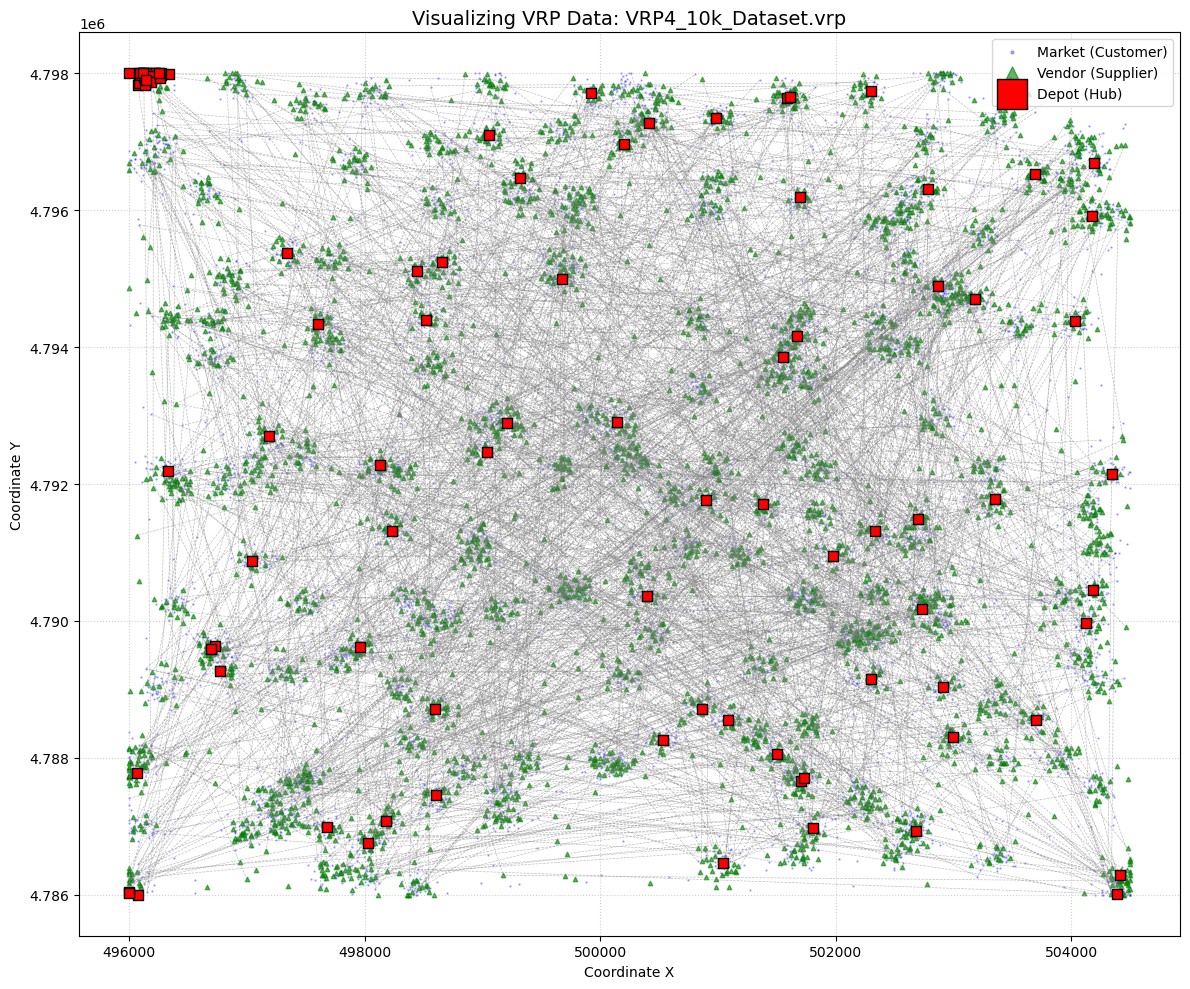

In [1]:
import matplotlib.pyplot as plt
import os

def visualize_vrp_file(file_path):
    print(f"--- Đang đọc và vẽ file: {file_path} ---")
    
    if not os.path.exists(file_path):
        print(f"❌ Lỗi: Không tìm thấy file {file_path}")
        return

    # Dữ liệu để vẽ
    coords = {}      # Lưu tọa độ {id: (x, y)}
    node_types = {}  # Lưu loại node {id: type}
    prohibited_edges = [] # Lưu cặp (source_id, target_id)

    # Các cờ để nhận biết section đang đọc
    section = None

    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        
    for line in lines:
        line = line.strip()
        if not line or line == "EOF": continue

        # Phát hiện Header Section
        if line.startswith("NODE_COORD_SECTION"):
            section = "COORD"
            continue
        elif line.startswith("NODE_TYPE_SECTION"):
            section = "TYPE"
            continue
        elif line.startswith("PROHIBITED_SECTION"):
            section = "PROHIBITED"
            continue
        elif "SECTION" in line: # Bỏ qua các section khác (Demand, Commodity...)
            section = "OTHER"
            continue

        # Đọc dữ liệu chi tiết
        parts = line.split()
        
        if section == "COORD":
            # Format: ID X Y
            nid, x, y = int(parts[0]), float(parts[1]), float(parts[2])
            coords[nid] = (x, y)
            
        elif section == "TYPE":
            # Format: ID Type (0=Depot, 1=Vendor, 2=Market)
            nid, ntype = int(parts[0]), int(parts[1])
            node_types[nid] = ntype
            
        elif section == "PROHIBITED":
            # Format: FromID ToID
            try:
                src, tgt = int(parts[0]), int(parts[1])
                prohibited_edges.append((src, tgt))
            except:
                pass

    # --- TIẾN HÀNH VẼ ---
    print(f"📊 Đang vẽ {len(coords)} nodes và {len(prohibited_edges)} cạnh cấm...")
    plt.figure(figsize=(12, 10))
    
    # Tách dữ liệu theo nhóm để vẽ màu khác nhau
    depots_x, depots_y = [], []
    vendors_x, vendors_y = [], []
    markets_x, markets_y = [], []

    for nid, (x, y) in coords.items():
        ntype = node_types.get(nid, 2) # Mặc định là Market nếu lỗi
        if ntype == 0: # Depot
            depots_x.append(x)
            depots_y.append(y)
        elif ntype == 1: # Vendor
            vendors_x.append(x)
            vendors_y.append(y)
        else: # Market
            markets_x.append(x)
            markets_y.append(y)

    # 1. Vẽ Node (Dùng scatter plot cho nhanh)
    # Market (Nhiều nhất -> vẽ trước, nhỏ nhất)
    plt.scatter(markets_x, markets_y, c='blue', s=2, alpha=0.3, label='Market (Customer)', marker='.')
    
    # Vendor
    plt.scatter(vendors_x, vendors_y, c='green', s=10, alpha=0.6, label='Vendor (Supplier)', marker='^')
    
    # Depot (Ít nhất -> vẽ sau cùng, to nhất)
    plt.scatter(depots_x, depots_y, c='red', s=50, edgecolors='black', label='Depot (Hub)', marker='s', zorder=10)

    # 2. Vẽ Cạnh Cấm (Prohibited Edges)
    # Chỉ vẽ tối đa 2000 cạnh để tránh treo máy nếu file quá lớn
    max_draw_edges = 2000
    if len(prohibited_edges) > max_draw_edges:
        print(f"⚠️ Chỉ vẽ {max_draw_edges}/{len(prohibited_edges)} cạnh cấm mẫu để không làm lag biểu đồ.")
    
    count = 0
    for src, tgt in prohibited_edges:
        if count >= max_draw_edges: break
        if src in coords and tgt in coords:
            p1 = coords[src]
            p2 = coords[tgt]
            # Vẽ đường nối màu xám
            plt.plot([p1[0], p2[0]], [p1[1], p2[1]], c='gray', linestyle='--', linewidth=0.5, alpha=0.5)
            count += 1
            
    # Trang trí
    plt.title(f"Visualizing VRP Data: {os.path.basename(file_path)}", fontsize=14)
    plt.xlabel("Coordinate X")
    plt.ylabel("Coordinate Y")
    plt.legend(markerscale=3) # Phóng to chú thích cho dễ nhìn
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Hiển thị
    plt.tight_layout()
    plt.show()

# --- CHẠY THỬ ---
# Thay tên file dưới đây bằng file bạn vừa tạo (ví dụ: output_vrp_final/VRP4_10k_Final.vrp)
file_to_view = "dataset/VRP4_10k_Dataset.vrp" 

visualize_vrp_file(file_to_view)

--- Đang đọc và vẽ file: dataset/VRP4_20k_Dataset.vrp ---
📊 Đang vẽ 20000 nodes và 3171 cạnh cấm...
⚠️ Chỉ vẽ 2000/3171 cạnh cấm mẫu để không làm lag biểu đồ.


C:\Users\thaip\AppData\Local\Temp\ipykernel_12780\1773402935.py:116: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


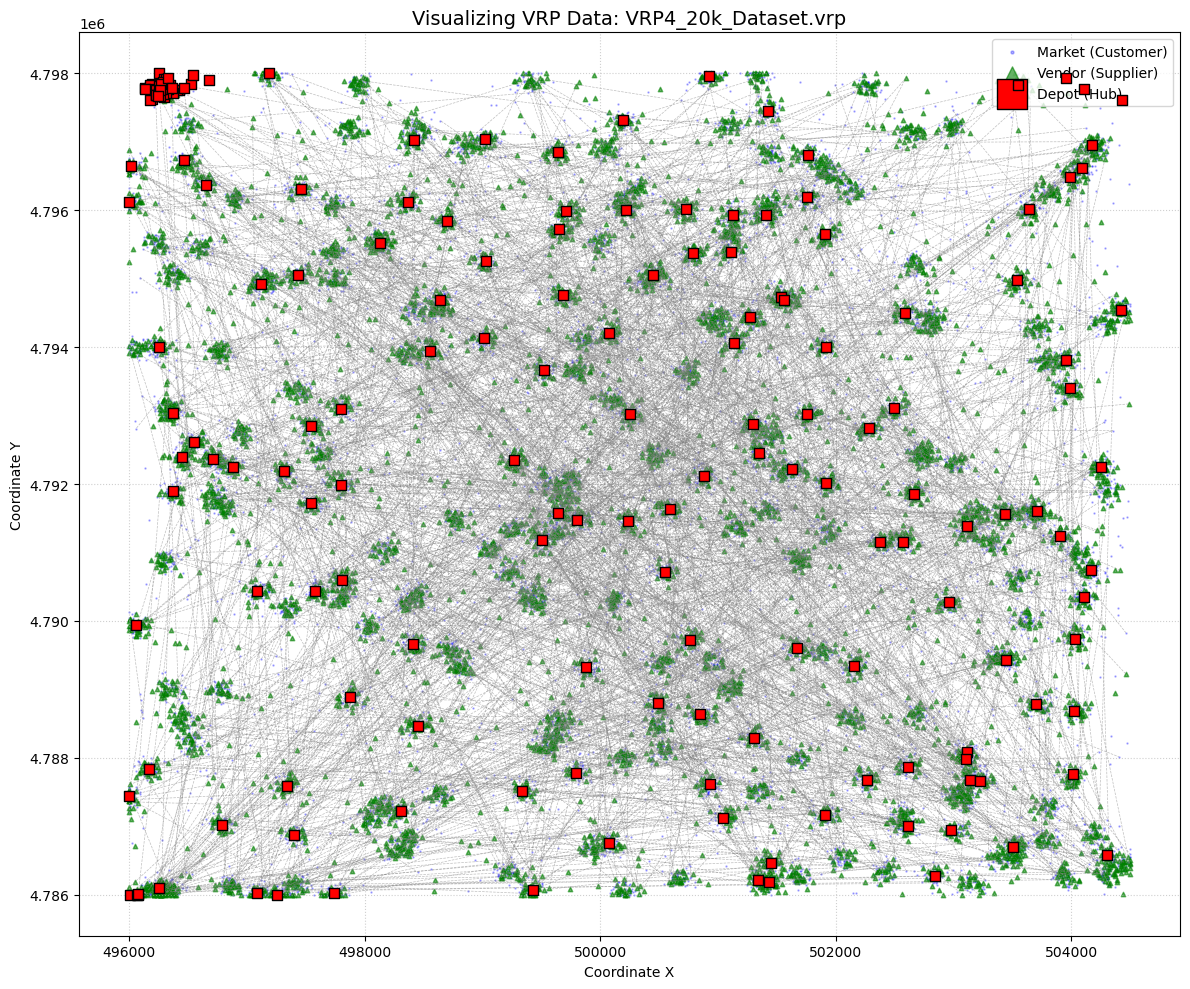

In [2]:
file_to_view = "dataset/VRP4_20k_Dataset.vrp" 

visualize_vrp_file(file_to_view)

--- Đang đọc và vẽ file: dataset/VRP4_30k_Dataset.vrp ---
📊 Đang vẽ 30000 nodes và 4554 cạnh cấm...
⚠️ Chỉ vẽ 2000/4554 cạnh cấm mẫu để không làm lag biểu đồ.


C:\Users\thaip\AppData\Local\Temp\ipykernel_12780\1773402935.py:116: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


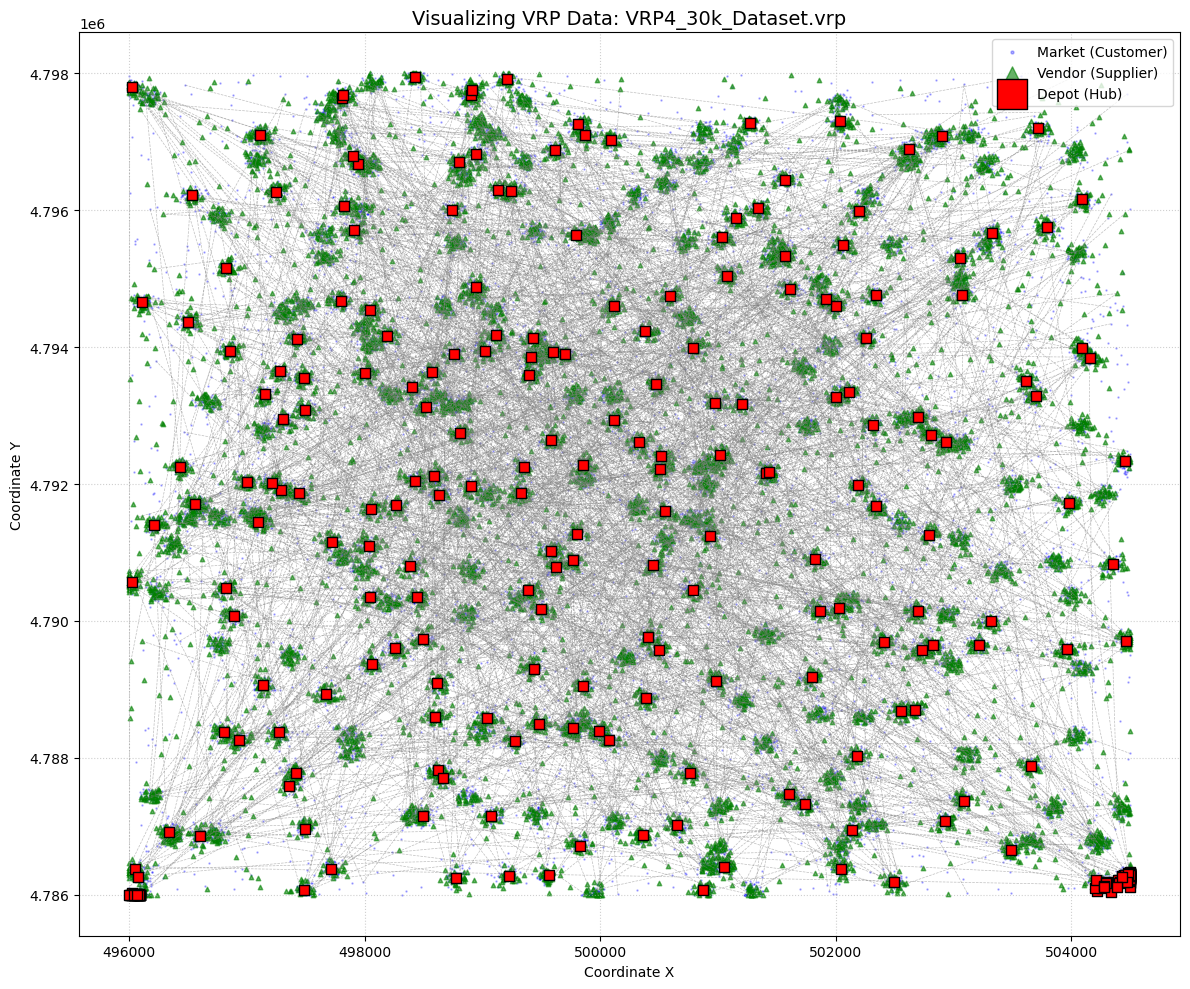

In [3]:
file_to_view = "dataset/VRP4_30k_Dataset.vrp" 

visualize_vrp_file(file_to_view)

--- Đang đọc và vẽ file: dataset/VRP4_40k_Dataset.vrp ---
📊 Đang vẽ 40000 nodes và 1844 cạnh cấm...


C:\Users\thaip\AppData\Local\Temp\ipykernel_12780\1773402935.py:116: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


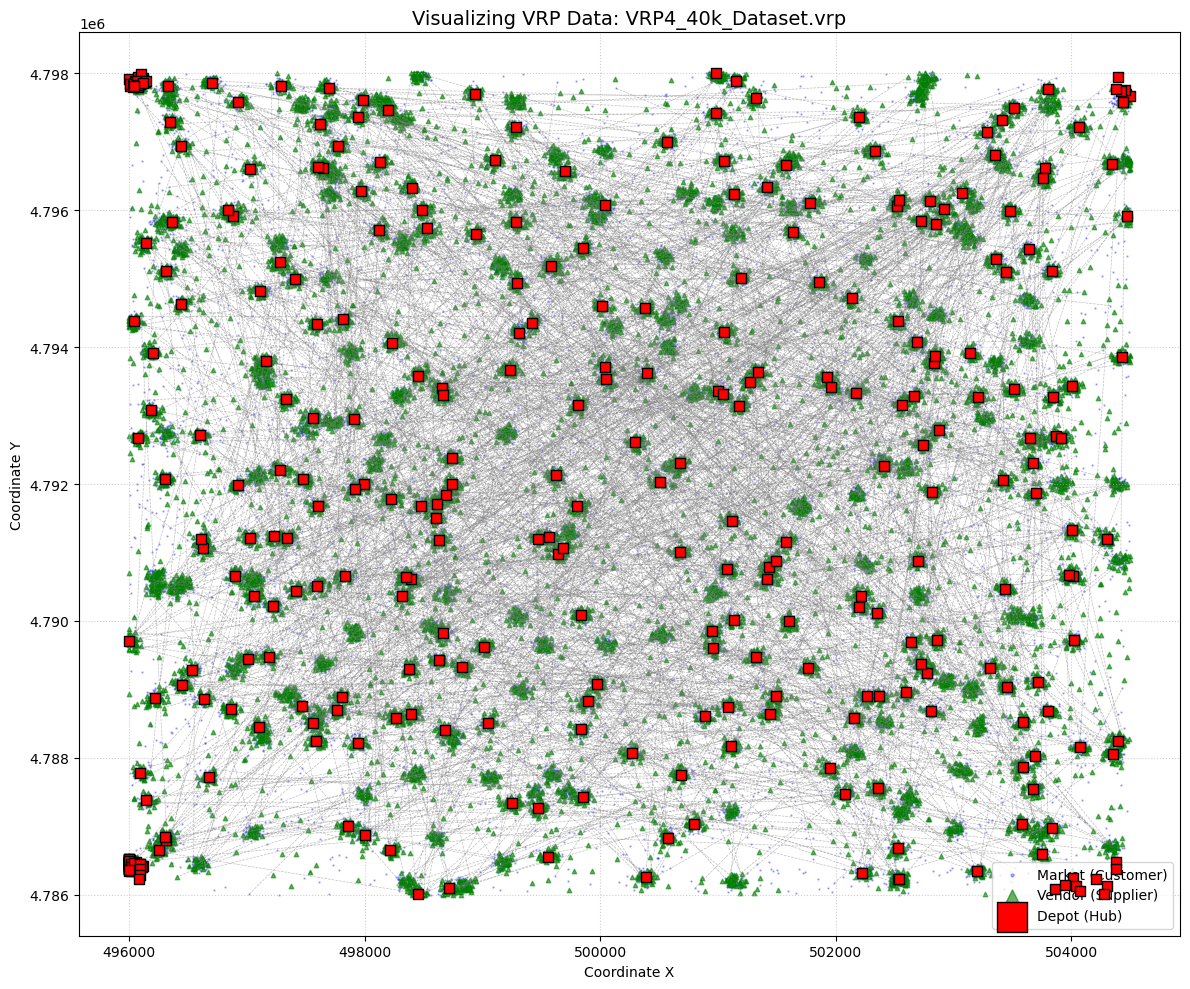

In [4]:
file_to_view = "dataset/VRP4_40k_Dataset.vrp" 

visualize_vrp_file(file_to_view)

In [ ]:
file_to_view = "dataset/VRP4_20k_Dataset.vrp" 

visualize_vrp_file(file_to_view)